In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install rasterio geopandas shapely planetary-computer pystac-client -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 22.3 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
BASE = '/content/drive/MyDrive/DAT103_Indonesia_Project'

#AOI bounding box (Bogor City(Indonesia))
AOI_BBOX = {
    'min_lon': 107.2831,
    'max_lon': 107.3471,
    'min_lat': -6.7023,
    'max_lat': -6.6383
}

LANDSAT_DIR = f'{BASE}/data/landsat/'
LULC_DIR = f'{BASE}/data/lulc/'
PROCESSED_DIR = f'{BASE}/data/processed/'
PATCHES_DIR = f'{BASE}/data/patches/'
MODELS_DIR = f'{BASE}/models/'
FIGURES_DIR = f'{BASE}/figures/'

import os
for d in [LANDSAT_DIR, LULC_DIR, PROCESSED_DIR, PATCHES_DIR, MODELS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)
print("Paths ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Paths ready.


In [ ]:
import rasterio
import glob

# Using Band 4
b4_path = glob.glob(f"{LANDSAT_DIR}/*_B4.TIF")[0]
with rasterio.open(b4_path) as src:
    LANDSAT_CRS = src.crs
    LANDSAT_BOUNDS = src.bounds
    LANDSAT_TRANSFORM = src.transform
    LANDSAT_SHAPE = src.shape

print(f"Target CRS: {LANDSAT_CRS}")

Target CRS: EPSG:32648


In [ ]:
import planetary_computer
import pystac_client

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

search = catalog.search(
    collections=["io-lulc-9-class"],
    bbox=[AOI_BBOX['min_lon'], AOI_BBOX['min_lat'],
          AOI_BBOX['max_lon'], AOI_BBOX['max_lat']],
)

items = list(search.items())
lulc_url = items[0].assets["data"].href
print(f"Streaming URL acquired!")

Streaming URL acquired!


In [ ]:
import numpy as np
from rasterio.mask import mask
from rasterio.warp import reproject, Resampling
from shapely.geometry import box
import geopandas as gpd

with rasterio.open(lulc_url) as lulc_src:
    # 1. Creating geometry and clipping to the AOI(50 km2), original downloaded was much large
    aoi_geom = box(AOI_BBOX['min_lon'], AOI_BBOX['min_lat'],
                   AOI_BBOX['max_lon'], AOI_BBOX['max_lat'])
    gdf = gpd.GeoDataFrame({'geometry': [aoi_geom]}, crs="EPSG:4326")
    gdf_reproj = gdf.to_crs(lulc_src.crs)

    clipped_lulc, clipped_transform = mask(lulc_src, gdf_reproj.geometry, crop=True)

    # 2 aligning resolution to landsat image(30m)
    print("Resampling 10m ESRI pixels to 30m Landsat grid...")

    reprojected_lulc = np.zeros((1, LANDSAT_SHAPE[0], LANDSAT_SHAPE[1]), dtype=clipped_lulc.dtype)

    reproject(
        source=clipped_lulc,
        destination=reprojected_lulc,
        src_transform=clipped_transform,
        src_crs=lulc_src.crs,
        dst_transform=LANDSAT_TRANSFORM,
        dst_crs=LANDSAT_CRS,
        resampling=Resampling.nearest
    )
    final_meta = lulc_src.meta.copy()
    final_meta.update({
        "driver": "GTiff",
        "height": LANDSAT_SHAPE[0],
        "width": LANDSAT_SHAPE[1],
        "transform": LANDSAT_TRANSFORM,
        "crs": LANDSAT_CRS
    })

# Saving
lulc_out_path = f"{PROCESSED_DIR}/lulc_reprojected.tif"
with rasterio.open(lulc_out_path, "w", **final_meta) as dest:
    dest.write(reprojected_lulc)

print(f"Saved perfectly aligned LULC map to: {lulc_out_path}")

Resampling 10m ESRI pixels to 30m Landsat grid...
Saved perfectly aligned LULC map to: /content/drive/MyDrive/DAT103_Indonesia_Project/data/processed//lulc_reprojected.tif


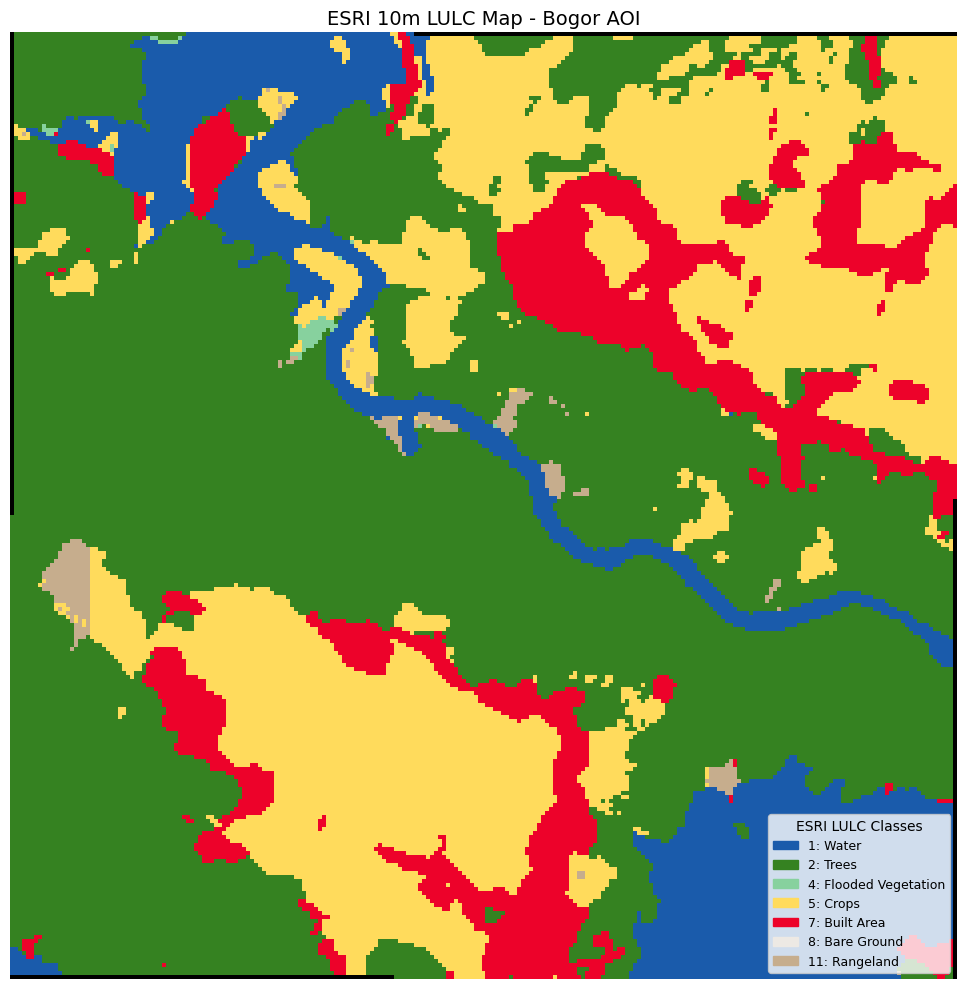

Saved lulc_map.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np

ESRI_CLASSES = {
    1: ("Water", "#1A5BAB"),
    2: ("Trees", "#358221"),
    4: ("Flooded Vegetation", "#87D19E"),
    5: ("Crops", "#FFDB5C"),
    7: ("Built Area", "#ED022A"),
    8: ("Bare Ground", "#EDE9E4"),
    11: ("Rangeland", "#C6AD8D")
}

lulc_data = reprojected_lulc[0]
h, w = lulc_data.shape

# Create a blank RGB image
rgb_image = np.zeros((h, w, 3))

# Painting the image with the exact hex colors based on the class numbers
for val, (name, hex_color) in ESRI_CLASSES.items():
    rgb_color = mcolors.to_rgb(hex_color)
    mask = (lulc_data == val)
    rgb_image[mask] = rgb_color

fig, ax = plt.subplots(figsize=(10, 10))

# Plotting the painted RGB image directly
ax.imshow(rgb_image)

legend_patches = [mpatches.Patch(color=color, label=f"{cid}: {name}")
                  for cid, (name, color) in ESRI_CLASSES.items()]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9,
          title="ESRI LULC Classes", framealpha=0.8)

ax.set_title("ESRI 10m LULC Map - Bogor AOI", fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/lulc_map.png", dpi=150, bbox_inches='tight')
plt.show()

print("Saved lulc_map.png")